In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ecdf, ks_2samp
import shap
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


rand_state = 23

# Credit Scoring — Home Credit Default Risk

## Cel projektu
Celem projektu jest zbudowanie modelu klasyfikacyjnego przewidującego,
czy klient spłaci pożyczkę (TARGET = 0) czy wpadnie w default (TARGET = 1).
Jest to klasyczny problem credit scoringu, stosowany w bankach i instytucjach
finansowych do oceny ryzyka kredytowego.

---
## 1. Wczytanie danych i analiza klasy docelowej

Zbiór danych pochodzi z konkursu Kaggle - Home Credit Default Risk.
Zawiera 307 511 klientów opisanych 122 cechami, takimi jak dochód,
kwota kredytu, historia zatrudnienia czy zewnętrzne oceny scoringowe.

Zmienna docelowa TARGET przyjmuje wartości:
- 0 — klient spłacił pożyczkę (brak defaultu)
- 1 — klient nie spłacił pożyczki (default)

Rozkład klas jest silnie niezbalansowany - tylko ~8% klientów
to default.

In [ ]:
df = pd.read_csv('application_train.csv')

In [36]:
print(df['TARGET'].value_counts(normalize=True)) 

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [38]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


---
## 2. Analiza brakujących wartości

Przed budową modelu sprawdzamy, które kolumny zawierają braki danych.
Kolumny z ponad 40% brakujących wartości odrzucamy.

Kolumny z największą liczbą braków (np. COMMONAREA_MEDI ~70%) dotyczą
charakterystyki nieruchomości — wielu klientów ich nie podało.

Po odrzuceniu kolumn z >40% braków pozostało 73 zmienne (z 122).
Braki w pozostałych kolumnach uzupełniamy:
- medianą — dla zmiennych numerycznych (odporna na wartości odstające)
- modą — dla zmiennych kategorycznych (najczęstsza kategoria)



COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
FLOORSMIN_AVG               0.678486
FLOORSMIN_MODE              0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_AVG             0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MEDI               0.593767
LANDAREA_MODE               0.593767
LANDAREA_AVG                0.593767
dtype: float64


<Axes: xlabel='TARGET'>

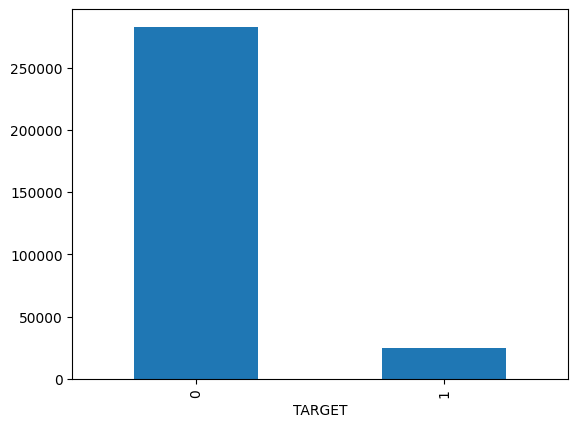

In [28]:
missing = df.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0].head(20))


df['TARGET'].value_counts().plot(kind='bar')

In [ ]:
threshold = 0.4
cols_to_drop = missing[missing > threshold].index.tolist()
df_clean = df.drop(columns=cols_to_drop)
print(f"Zostało kolumn: {df_clean.shape[1]}")

cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['SK_ID_CURR', 'TARGET']]

print(f"Numeryczne: {len(num_cols)}, Kategoryczne: {len(cat_cols)}")

df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())
df_clean[cat_cols] = df_clean[cat_cols].fillna(df_clean[cat_cols].mode().iloc[0])

Zostało kolumn: 73
Numeryczne: 59, Kategoryczne: 12


---
## 3. Przygotowanie danych do modelowania

### Encoding zmiennych kategorycznych
Modele matematyczne operują wyłącznie na liczbach. Zmienne kategoryczne
(np. NAME_CONTRACT_TYPE, CODE_GENDER) zamieniamy na liczby całkowite
przy użyciu Label Encodera.

### Podział na zbiór treningowy i testowy
Dane dzielimy w proporcji 80/20:
- zbiór treningowy (246 008 obs.) — służy do uczenia modelu
- zbiór testowy (61 503 obs.) — służy do oceny modelu na nowych danych

Parametr stratify=y zapewnia, że obie klasy (0 i 1) są reprezentowane
proporcjonalnie w obu zbiorach. Jest to szczególnie ważne przy
niezbalansowanych danych.

In [ ]:
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

X = df_clean.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df_clean['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=rand_state, stratify=y
)
print(X_train.shape, X_test.shape)

(246008, 71) (61503, 71)


---

## 4. Model 1 — Regresja logistyczna

Regresja logistyczna to podstawowy i najczęściej stosowany model
w bankowym credit scoringu. Szacuje prawdopodobieństwo defaultu jako:

    P(default) = 1 / (1 + exp(-(β₀ + β₁x₁ + ... + βₙxₙ)))

gdzie β to współczynniki modelu, a x to cechy klienta.

Zalety w kontekście bankowym:
- wysoka interpretowalność — regulator może zażądać wyjaśnienia
  każdej decyzji kredytowej
- łatwość kalibracji do rzeczywistych prawdopodobieństw defaultu
- standard w modelach IRB (Internal Ratings-Based) wymaganych przez Basel

Przed dopasowaniem modelu skalujemy dane (StandardScaler), ponieważ
regresja logistyczna jest wrażliwa na różne skale zmiennych.


AUC:  0.7353
Gini: 0.4707


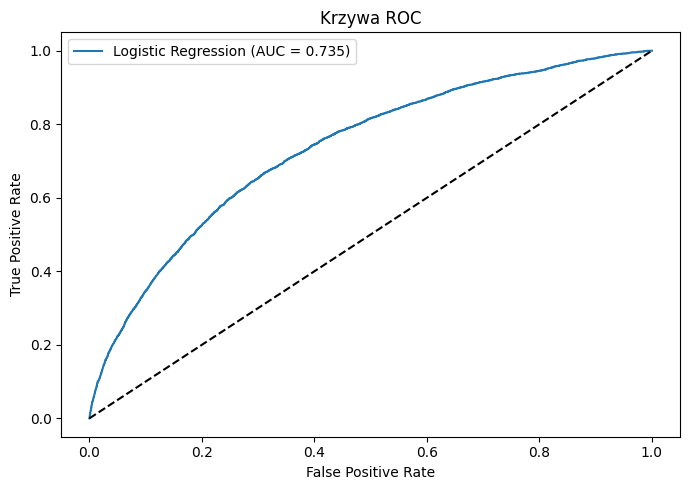

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=rand_state)
model.fit(X_train_sc, y_train)

y_prob = model.predict_proba(X_test_sc)[:, 1]

auc = roc_auc_score(y_test, y_prob)
gini = 2 * auc - 1
print(f"AUC:  {auc:.4f}")
print(f"Gini: {gini:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywa ROC')
plt.legend()
plt.tight_layout()
plt.show()

---

## 5. Metryki walidacji modeli klasyfikacyjnych


### Krzywa ROC (Receiver Operating Characteristic)

Krzywa ROC jest graficzną reprezentacją zdolności dyskryminacyjnej klasyfikatora binarnego. Konstruowana jest poprzez wyznaczenie par $(\text{FPR}, \text{TPR})$ dla wszystkich możliwych progów decyzyjnych $t \in [0,1]$, gdzie:

$$\text{TPR}(t) = \frac{TP(t)}{TP(t) + FN(t)}, \qquad \text{FPR}(t) = \frac{FP(t)}{FP(t) + TN(t)}$$

- **TPR** (True Positive Rate, czułość) — odsetek defaulterów poprawnie sklasyfikowanych jako defaulterzy
- **FPR** (False Positive Rate) — odsetek nie-defaulterów błędnie sklasyfikowanych jako defaulterzy

Punkt $(0, 0)$ odpowiada progowi $t = 1$ (wszystkie obserwacje klasyfikowane jako $0$), punkt $(1, 1)$ odpowiada progowi $t = 0$ (wszystkie jako $1$). Przekątna wykresu odpowiada klasyfikatorowi losowemu.


**Oś X — False Positive Rate (FPR)**

$$\text{FPR} = \frac{FP}{FP + TN}$$

Spośród wszystkich klientów, którzy **naprawdę nie są defaulterami** ($\text{TARGET} = 0$),
jaki odsetek model błędnie oznaczył jako defaultera?

W praktyce kredytowej: jaki odsetek dobrych klientów niesłusznie odrzuciliśmy.


**Oś Y — True Positive Rate (TPR)**

$$\text{TPR} = \frac{TP}{TP + FN}$$

Spośród wszystkich klientów, którzy **naprawdę są defaulterami** ($\text{TARGET} = 1$),
jaki odsetek model poprawnie wykrył?

W praktyce kredytowej: jaki odsetek złych klientów skutecznie zatrzymaliśmy.


**Próg decyzyjny $t$**

Model nie wydaje wyroku "default / nie-default" bezpośrednio — zwraca
**prawdopodobieństwo** $\hat{p} \in [0,1]$. Dopiero my ustalamy próg $t$:

$$\text{decyzja} = \begin{cases} \text{default} & \hat{p} \geq t \\ \text{nie-default} & \hat{p} < t \end{cases}$$

Każdy próg $t$ daje inną parę $(\text{FPR}, \text{TPR})$ — jeden punkt na wykresie ROC.
Krzywa ROC to zbiór wszystkich takich punktów dla $t \in [0,1]$.


**Trade-off w decyzji kredytowej**

Obniżając próg $t$ (bardziej rygorystyczna polityka kredytowa):

- $\text{TPR}$ rośnie — wykrywamy więcej defaulterów ✓
- $\text{FPR}$ rośnie — odrzucamy też więcej dobrych klientów ✗

Bank musi wybrać punkt na krzywej ROC odpowiadający jego strategii —
czy bardziej kosztowne jest udzielenie złej pożyczki, czy odrzucenie dobrego klienta.

---

### AUC (Area Under the ROC Curve)

AUC definiowane jest jako pole powierzchni pod krzywą ROC:

$$\text{AUC} = \int_0^1 \text{TPR}\!\left(\text{FPR}^{-1}(u)\right) du$$


| AUC | Interpretacja |
|:---:|:---|
| $0.5$ | Klasyfikator losowy |
| $0.7 - 0.8$ | Model akceptowalny |

---

### Współczynnik Giniego

Współczynnik Giniego jest liniową funkcją AUC:

$$\text{Gini} = 2 \cdot \text{AUC} - 1$$

Geometrycznie, Gini wyraża stosunek pola między krzywą ROC a przekątną do pola trójkąta powyżej przekątnej:

$$\text{Gini} = \frac{\text{pole między krzywą ROC a przekątną}}{\text{pole trójkąta powyżej przekątnej}}$$

Przyjmuje wartości $\text{Gini} \in [0, 1]$, gdzie $0$ odpowiada klasyfikatorowi losowemu, a $1$ — perfekcyjnemu. Jest preferowaną miarą w praktyce bankowej ze względu na bardziej intuicyjną skalę — bezpośrednio wyraża procentową poprawę względem klasyfikatora losowego.

---

### Statystyka KS (Kolmogorov–Smirnov)

Statystyka KS mierzy maksymalną różnicę między empirycznymi dystrybuantami przewidywanych prawdopodobieństw w grupie defaulterów i nie-defaulterów:

$$\text{KS} = \sup_{t \in [0,1]} \left| F_1(t) - F_0(t) \right|$$

gdzie $F_1(t)$ i $F_0(t)$ to empiryczne dystrybuanty prawdopodobieństw predykowanych odpowiednio dla klasy $1$ i klasy $0$.


W kontekście credit scoringu KS informuje, w którym punkcie skali scoringowej model najlepiej separuje defaulterów od nie-defaulterów.


In [44]:
probs_default = y_prob[y_test == 1]
probs_non_default = y_prob[y_test == 0]

ks_stat, ks_pvalue = ks_2samp(probs_default, probs_non_default)
print(f"KS Statistic: {ks_stat:.4f}")

KS Statistic: 0.3565


---

## 6. Model 2 — XGBoost

XGBoost (Extreme Gradient Boosting) to model oparty na zespole drzew
decyzyjnych budowanych sekwencyjnie. Każde kolejne drzewo koryguje błędy
poprzedniego, minimalizując funkcję straty metodą gradientową.

W przeciwieństwie do regresji logistycznej XGBoost:
- wykrywa nieliniowe zależności między zmiennymi
- automatycznie modeluje interakcje między cechami
- nie wymaga skalowania danych

Wyniki:
- Regresja logistyczna: AUC = 0.735, Gini = 0.471
- XGBoost:             AUC = 0.749, Gini = 0.498

XGBoost osiąga lepszy wynik, jednak kosztem interpretowalności.


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=rand_state,
    eval_metric='auc',
    verbosity=0
)
xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
gini_xgb = 2 * auc_xgb - 1
print(f"XGBoost AUC:  {auc_xgb:.4f}")
print(f"XGBoost Gini: {gini_xgb:.4f}")

XGBoost AUC:  0.7489
XGBoost Gini: 0.4977


---

## 7. Interpretowalność modelu — wartości SHAP

SHAP (SHapley Additive exPlanations) to metoda wyjaśniania predykcji
modeli ML, oparta na teorii gier kooperacyjnych. Dla każdej cechy
i każdego klienta oblicza, o ile zmieniła się predykcja modelu
względem średniej dzięki uwzględnieniu tej cechy.

Na wykresie summary plot:
- każdy punkt to jeden klient
- pozycja na osi X = wpływ cechy na predykcję (+ zwiększa ryzyko, - zmniejsza)
- kolor = wartość cechy (czerwony = wysoka, niebieski = niska)

Wnioski z wykresu:
- EXT_SOURCE_3 i EXT_SOURCE_2 (zewnętrzne oceny scoringowe) to zdecydowanie
  najważniejsze cechy — wysoka wartość (czerwony) silnie obniża ryzyko
- AMT_GOODS_PRICE i AMT_CREDIT — wyższe kwoty zwiększają ryzyko defaultu
- DAYS_BIRTH — starsi klienci (wyższa wartość bezwzględna) są mniej ryzykowni
- DAYS_EMPLOYED — dłuższy staż pracy obniża ryzyko

SHAP pozwala odpowiedzieć na pytanie regulatora:
"Dlaczego odmówiono temu klientowi kredytu?"

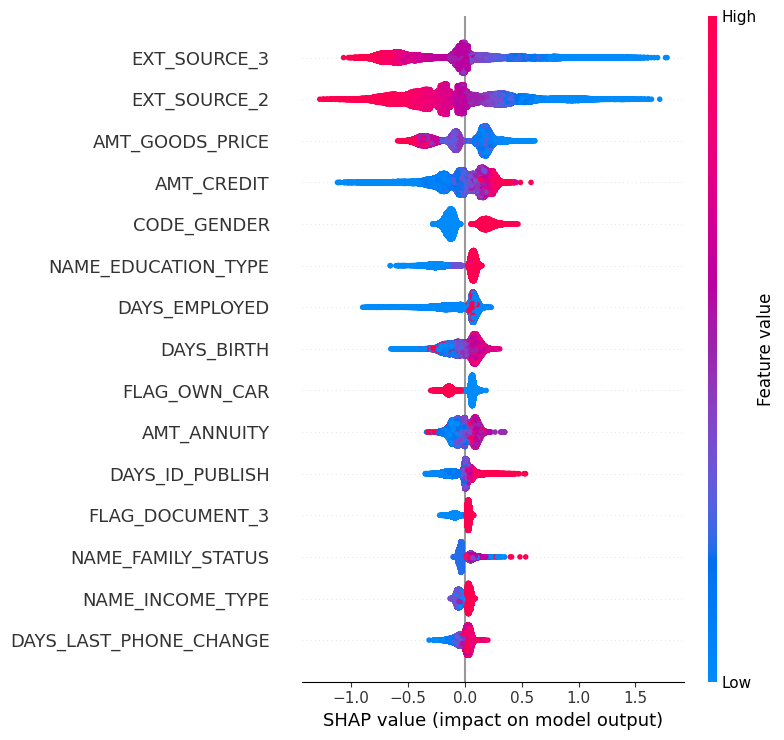

In [45]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=15)

---

## 8. Porównanie modeli

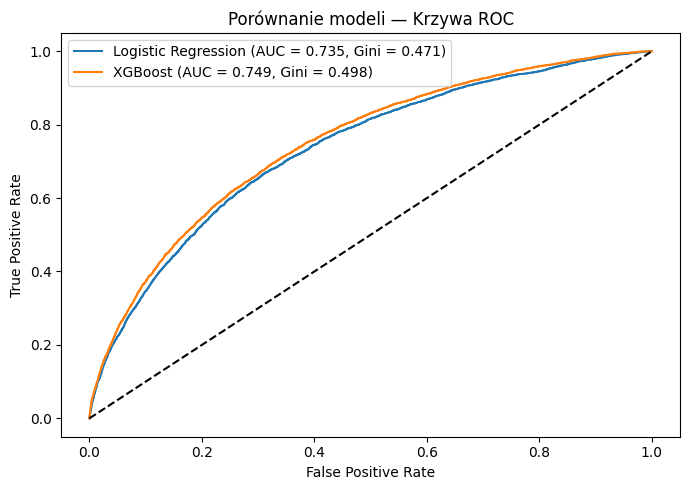

In [41]:

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f}, Gini = {gini:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f}, Gini = {gini_xgb:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Porównanie modeli — Krzywa ROC')
plt.legend()
plt.tight_layout()
plt.show()